In [1]:
import sys
import os
print(os.getcwd())
sys.path.append(os.getcwd())
from utils import fcla as fc
from utils import simulation_utils as su
from utils import data_visualization as dv

c:\Users\alejo\Desktop\intro_la_inv


Test llm models

nvidia


In [5]:
model = "qwen3:4b"
text = su.test_llm(model,'ollama')
print(text)

[Ollama] Verificando/Descargando el modelo 'qwen3:4b'...
 -> Status: pulling manifest
 -> Status: pulling 3e4cb1417446
 -> Status: pulling 2d54db2b9bb2
 -> Status: pulling d18a5cc71b84
 -> Status: pulling cff3f395ef37
 -> Status: pulling e18a783aae55
 -> Status: verifying sha256 digest
 -> Status: writing manifest
 -> Status: success
[Ollama] Procesando tu consulta...
[Ollama RESPUESTA]: The query mentions "E = 1000" in the context of price elasticity of demand, but this is ambiguous. Price elasticity of demand (typically denoted as \(E_d\)) is a **dimensionless ratio** (e.g., -2 for inelastic demand), not a monetary value like $1000. The value "1000" likely refers to a **price level** (e.g., $1000), not the elasticity itself.

### Clarification:
- **Price elasticity of demand (\(E_d\))**: Measures how quantity demanded responds to a price change. It is calculated as:
  \[
  E_d = \frac{\%\ \text{change in quantity demanded}}{\%\ \text{change in price}}
  \]
  - \(E_d\) is **never** a 

ollama

In [2]:
model = "qwen3:4b"
text = su.test_llm(model,"ollama")
print(text)

[Ollama] Procesando tu consulta con el modelo 'qwen3:4b'...
[Ollama] Verificando/Descargando el modelo 'qwen3:4b'...
 -> Status: pulling manifest
 -> Status: pulling 3e4cb1417446
 -> Status: pulling 2d54db2b9bb2
 -> Status: pulling d18a5cc71b84
 -> Status: pulling cff3f395ef37
 -> Status: pulling e18a783aae55
 -> Status: verifying sha256 digest
 -> Status: writing manifest
 -> Status: success
[Ollama] Procesando tu consulta...
[Ollama RESPUESTA]: In economics, a во reference price is a mental benchmark that consumers use to evaluate the price of a product or service. It acts as a comparison point that influences how people perceive value and make purchasing decisions. Here's a concise explanation:

### Key Points:
1. **Definition**: A reference price is not an actual price but a psychological anchor consumers use to judge whether a product's price is "fair" or "reasonable."
2. **How It Works**:
   - If the **actual price is lower** than the reference price → Consumers perceive it as a 

Nvidia


# Simulations

## 1) Simulation withouth llms 

Inicializando entorno clásico
Starting Hybrid Simulation (FCNAgents + FCLAgents)...
# INITIALIZATION TIME 0.0655967
# EXECUTION TIME 0.4938123
Simulation complete successfully.
Data saved on './results/no_llms_base_results_fcn.csv'

=== ESTADÍSTICAS DE ÓRDENES colocadas ===
Órdenes totales de Agentes Clásicos (FCN): 500
Órdenes totales de Agentes con IA (LLM):  0

--- MUESTRA DE ÓRDENES CLÁSICAS (FCNAgent) ---
   market_time  agent_id  is_buy     price  volume         kind agent_type
0            0       248    True  19900.68       1  LIMIT_ORDER   FCNAgent
1            1       105   False  15456.31       1  LIMIT_ORDER   FCNAgent
2            2       242   False  14859.68       1  LIMIT_ORDER   FCNAgent
3            3       214    True  18090.97       1  LIMIT_ORDER   FCNAgent
4            4       353   False   1429.30       1  LIMIT_ORDER   FCNAgent
5            5       392   False   6347.99       1  LIMIT_ORDER   FCNAgent
6            6       454   False  12494.79       1  LIMIT_ORD

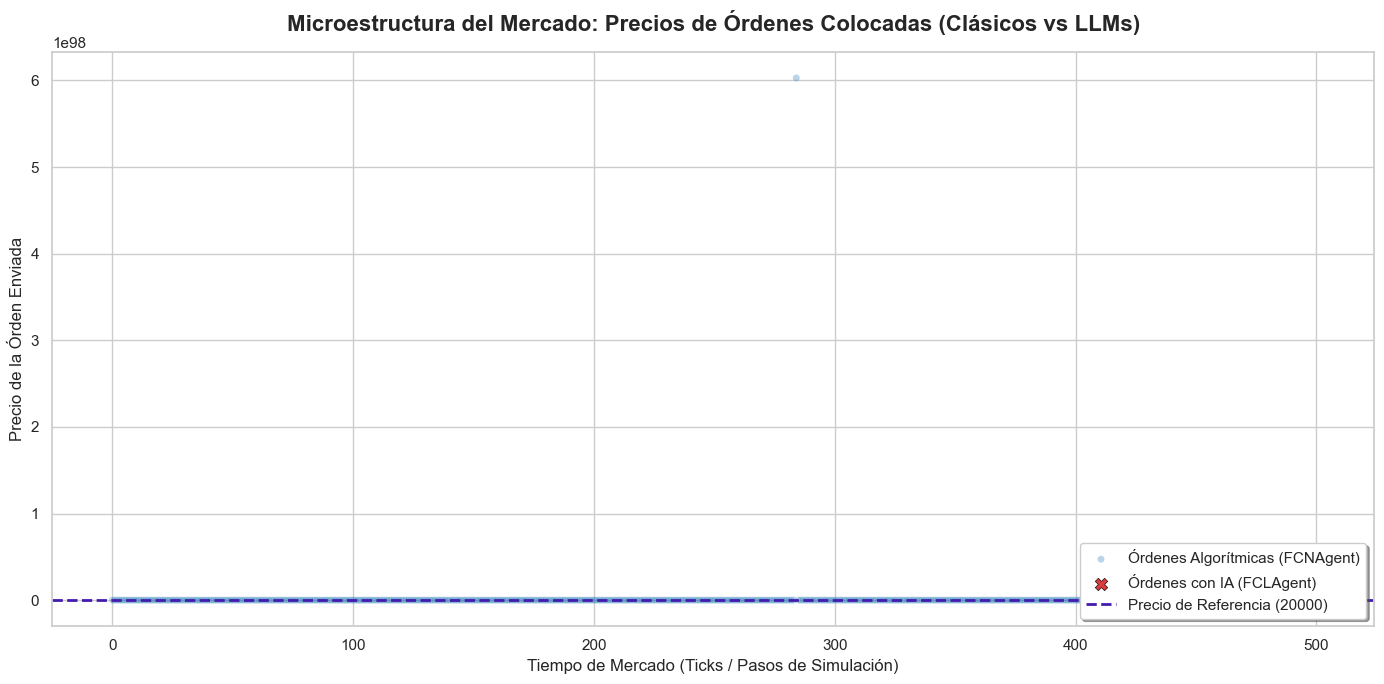

In [2]:
import warnings

# Ignorar las advertencias de redondeo del tick size para limpiar la consola
warnings.filterwarnings("ignore", category=UserWarning, module="pams.market")
market_runner, market_logger = su.run_sim("./jsons/config.json","no_llms")

llm_df,cls_df = su.agents_order_separation(market_runner,market_logger)
dv.plot_agent_actions_vs_time(cls_df,llm_df,20000)


Columnas exportadas por PAMS: ['session_id', 'market_time', 'market_id', 'market_name', 'market_price', 'fundamental_price']


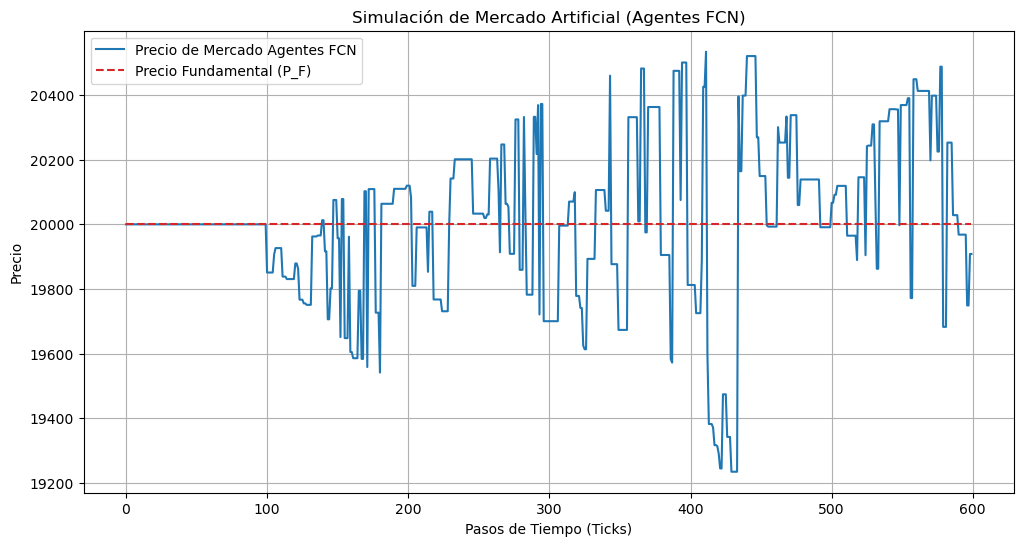

In [4]:
from utils import data_visualization as dv
r_path = "./results/no_llms_base_results_fcn.csv"
dv.market_behaviour(r_path)


## 2) Simulation with llms

In [5]:

from utils import personalities as pr
from utils import simulation_utils as su
import importlib
json_path = "./jsons/agenticConfig.json"
llm_runner,llm_logger = su.run_sim(json_path,"llm_hybrid",hybrid=True)
importlib.reload(fc)


Inicializando entorno híbrido...
Starting Hybrid Simulation (FCNAgents + FCLAgents)...
[SETUP] Agente FCL 95 creado con Personalidad: 'Baleas_Arriesgadas'
[SETUP] Agente FCL 96 creado con Personalidad: 'Baleas_Arriesgadas'
[SETUP] Agente FCL 97 creado con Personalidad: 'Conservadores_Miedosos'
[SETUP] Agente FCL 98 creado con Personalidad: 'Conservadores_Miedosos'
[SETUP] Agente FCL 99 creado con Personalidad: 'Conservadores_Miedosos'
  -> Agente 95 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 98 (Conservadores_Miedosos) - API (ollama): HOLD
  -> Agente 98 (Conservadores_Miedosos) - API (ollama): HOLD
  -> Agente 97 (Conservadores_Miedosos) - API (ollama): HOLD
  -> Agente 95 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 96 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 97 (Conservadores_Miedosos) - API (ollama): HOLD
  -> Agente 95 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 95 (Baleas_Arriesgadas) - API (ollama): BUY
  -> Agente 95 (Baleas_Arriesgadas) -

<module 'utils.fcla' from 'c:\\Users\\alejo\\Desktop\\intro_la_inv\\utils\\fcla.py'>

visualización 

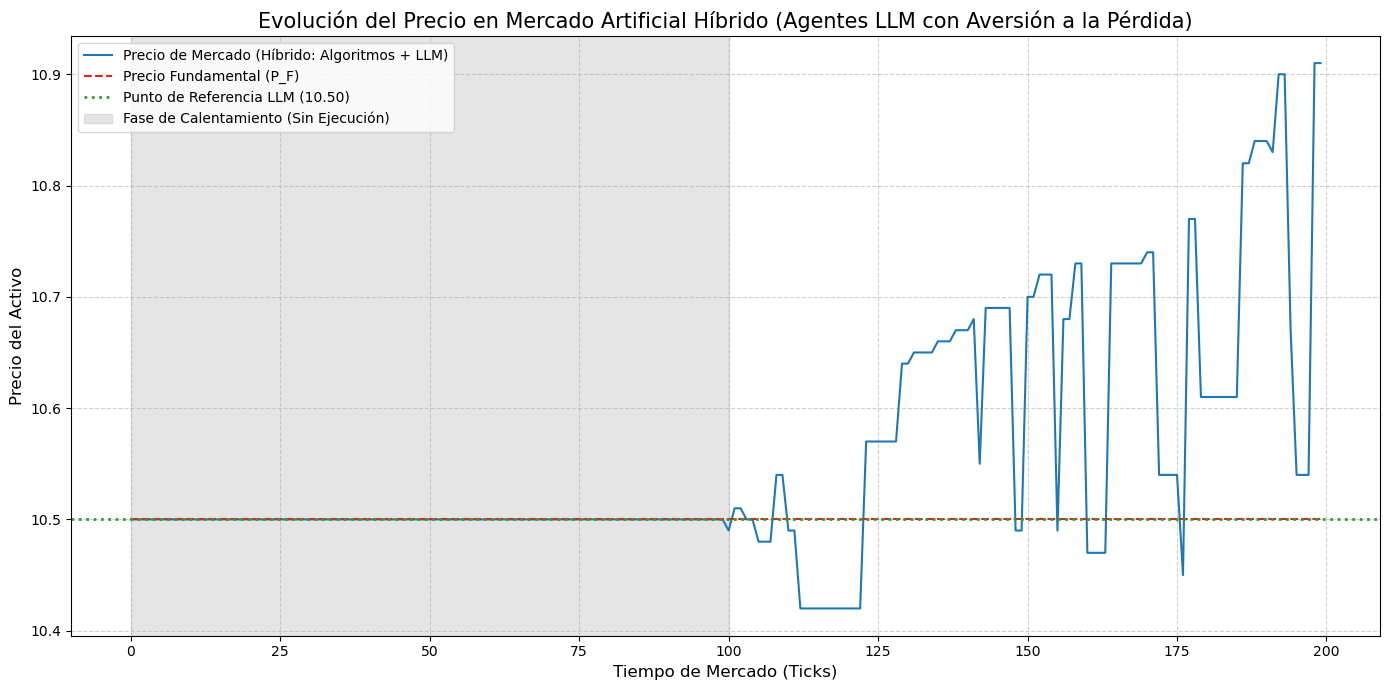


📊 RESUMEN ESTADÍSTICO DE LA SIMULACIÓN
▶ Precio Inicial:        10.5100
▶ Precio Final:          10.9100
▶ Precio Máximo (Pico):  10.9100
▶ Precio Mínimo (Caída): 10.4200
▶ Volatilidad (Desv. E): 0.1315


In [6]:
from utils import data_visualization as dv
import pandas as pd
import matplotlib.pyplot as plt
llm_r_path = "./results/llm_hybrid_base_results_fcn.csv"
dv.hybrid_market_behaviour(llm_r_path)
df = pd.read_csv(llm_r_path)
su.statistical_info(df)

 Análisis de Comportamiento Individual de Órdenes

In [ ]:

llm_df,cls_df = su.agents_order_separation(llm_runner,llm_logger)


=== ESTADÍSTICAS DE ÓRDENES colocadas ===
Órdenes totales de Agentes Clásicos (FCN): 196
Órdenes totales de Agentes con IA (LLM):  4

--- MUESTRA DE ÓRDENES CLÁSICAS (FCNAgent) ---
    market_time  agent_id  is_buy  price  volume         kind agent_type
1             1        18    True   9.63       1  LIMIT_ORDER   FCNAgent
2             2        47    True   9.87       1  LIMIT_ORDER   FCNAgent
3             3        32    True   9.87       1  LIMIT_ORDER   FCNAgent
4             4        55    True   9.71       1  LIMIT_ORDER   FCNAgent
5             5        15   False  10.48       1  LIMIT_ORDER   FCNAgent
6             6        23    True  10.11       1  LIMIT_ORDER   FCNAgent
7             7        92    True  10.20       1  LIMIT_ORDER   FCNAgent
8             8        54    True   9.58       1  LIMIT_ORDER   FCNAgent
9             9         6    True   9.91       1  LIMIT_ORDER   FCNAgent
10           10        28   False  10.85       1  LIMIT_ORDER   FCNAgent

--- MUESTRA DE

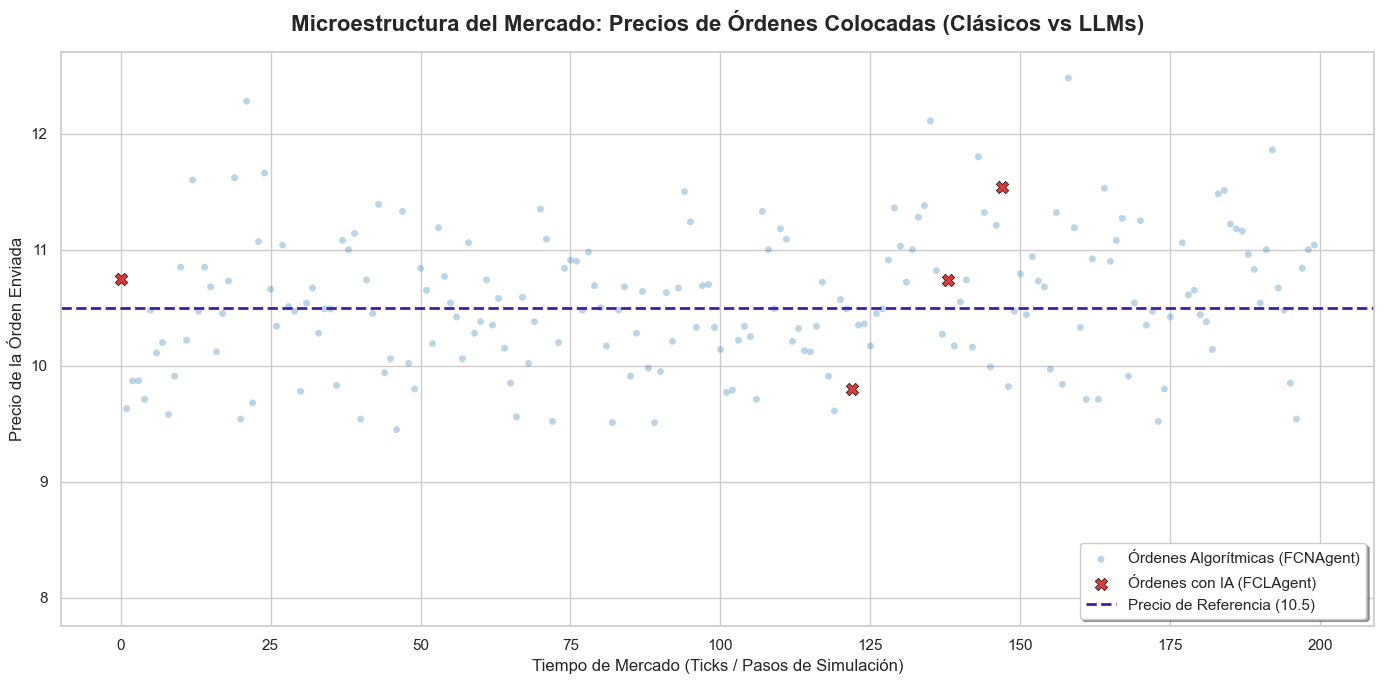

In [ ]:

dv.plot_agent_actions_vs_time(cls_df,llm_df,10.50)
